# Attention Mechanism

注意力 = "让模型自己决定看哪里"。本课从检索类比出发，实现缩放点积注意力，解释为什么除以 $\sqrt{d_k}$，并实现多头注意力。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 从检索到注意力


数据库检索：用 query 匹配 key，取出对应的 value。注意力把它变成**可微、可学习**的版本：

- **Query** $Q$：我要找什么
- **Key** $K$：每个位置提供什么标签
- **Value** $V$：每个位置的内容

匹配强度（相似度）→ softmax 归一化成权重 → 加权求和 value。

$$\text{Attention}(Q, K, V) = \text{softmax}\Big(\frac{QK^\mathsf{T}}{\sqrt{d_k}}\Big)V$$


In [2]:
B, T, d = 2, 5, 8
Q = torch.randn(B, T, d); K = torch.randn(B, T, d); V = torch.randn(B, T, d)

scores = Q @ K.transpose(-2, -1) / math.sqrt(d)
probs = torch.softmax(scores, dim=-1)
out = probs @ V

# 与 PyTorch 官方实现对拍
out_ref = F.scaled_dot_product_attention(Q, K, V)
print(f"输出形状: {out.shape}")
print(f"与 F.scaled_dot_product_attention 最大误差: {torch.abs(out - out_ref).max():.2e}")
print(f"注意力权重行和: {probs[0,0].sum():.4f}（每行是概率分布 ✓）")


输出形状: torch.Size([2, 5, 8])
与 F.scaled_dot_product_attention 最大误差: 2.38e-07
注意力权重行和: 1.0000（每行是概率分布 ✓）


## 2. 为什么要除以 √d_k：方差分析


设 $q_i, k_j$ 各分量独立零均值方差 1（$d$ 维），则点积 $q \cdot k$ 的方差为 $d$（独立同分布求和）：

$$\mathrm{Var}[q\cdot k] = \sum_{i=1}^d \mathrm{Var}[q_i k_i] = d$$

不缩放时，$d$ 越大 softmax 输入越极端 → 概率坍缩到 one-hot（梯度消失）。除以 $\sqrt d$ 把方差拉回 1。


In [3]:
rng = np.random.default_rng(0)
for d in [1, 8, 64, 256]:
    Q = rng.standard_normal((2000, d)); K = rng.standard_normal((2000, d))
    dots = (Q * K).sum(1)
    raw = np.exp(dots - dots.max()); p_raw = raw/raw.sum()
    scaled = np.exp(dots/np.sqrt(d) - (dots/np.sqrt(d)).max()); p_s = scaled/scaled.sum()
    print(f"d={d:4d}  点积标准差={dots.std():5.2f}（≈√d）  不缩放 max 概率={p_raw.max():.3f}  缩放后={p_s.max():.3f}")
print("→ 不缩放：d 大时 softmax 趋于 one-hot；除以 √d 后分布保持平滑")


d=   1  点积标准差= 1.01（≈√d）  不缩放 max 概率=0.097  缩放后=0.097
d=   8  点积标准差= 2.78（≈√d）  不缩放 max 概率=0.451  缩放后=0.020
d=  64  点积标准差= 8.01（≈√d）  不缩放 max 概率=0.418  缩放后=0.007
d= 256  点积标准差=15.83（≈√d）  不缩放 max 概率=0.480  缩放后=0.005
→ 不缩放：d 大时 softmax 趋于 one-hot；除以 √d 后分布保持平滑


## 3. 注意力矩阵的直觉


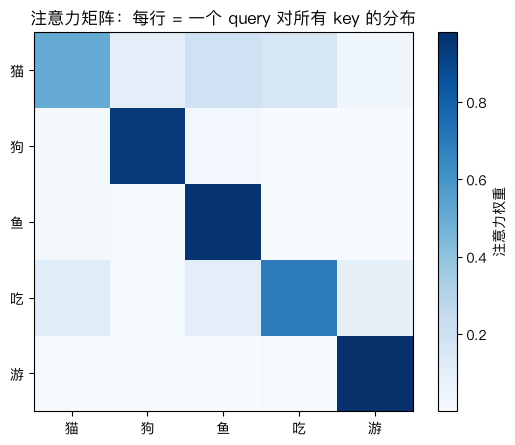

In [4]:
# 一个语义相似度示例：词向量点积 → 注意力权重
words = ['猫', '狗', '鱼', '吃', '游']
emb = torch.randn(5, 16)
sim = emb @ emb.T
probs = torch.softmax(sim / math.sqrt(16), dim=-1)

plt.figure(figsize=(5.5, 4.5))
plt.imshow(probs.numpy(), cmap='Blues')
plt.colorbar(label='注意力权重')
plt.xticks(range(5), words); plt.yticks(range(5), words)
plt.title('注意力矩阵：每行 = 一个 query 对所有 key 的分布')
plt.tight_layout()


## 4. 多头注意力


单头注意力只能学习一种"匹配模式"。多头把 $d_{model}$ 切成 $n_{heads}$ 个子空间，各自独立注意力再拼接：

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)W^O$$

不同头可以分别关注"位置关系""语义相似""句法角色"。


In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model, self.n_heads = d_model, n_heads
        self.d_k = d_model // n_heads
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.Wo = nn.Linear(d_model, d_model)
    def forward(self, x):
        B, T, _ = x.shape
        Q = self.Wq(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = self.Wk(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.Wv(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        attn = torch.softmax(scores, dim=-1)
        out = attn @ V
        out = out.transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.Wo(out)

mha = MultiHeadAttention(16, 4)
x = torch.randn(2, 7, 16)
print("多头输出形状:", tuple(mha(x).shape), "（B, T, d_model 不变 ✓）")
print(f"参数数量 = {sum(p.numel() for p in mha.parameters())}（4 个 Linear 含偏置：3×272 + 272）")


多头输出形状: (2, 7, 16) （B, T, d_model 不变 ✓）
参数数量 = 1088（4 个 Linear 含偏置：3×272 + 272）


## 5. 注意力的概率视角


softmax 权重是"关于 key 位置的概率分布"（衔接概率 06）：熵低 = 注意力集中（只盯一个位置）；熵高 = 注意力分散。**温度**同样适用（概率 08 课）——低温度让注意力更尖锐。


In [6]:
probs = torch.softmax(torch.randn(1, 1, 6) / math.sqrt(8), dim=-1)[0, 0]
H = -(probs * torch.log(probs + 1e-12)).sum()
print(f"注意力权重: {probs.numpy().round(3)}")
print(f"熵 = {H.item():.3f}（对比均匀分布熵 = {np.log(6):.3f}）")
print("→ 熵越小，注意力越集中；训练中模型自动学会集中/分散")


注意力权重: [0.165 0.126 0.173 0.191 0.139 0.206]
熵 = 1.778（对比均匀分布熵 = 1.792）
→ 熵越小，注意力越集中；训练中模型自动学会集中/分散


## 课后练习


1. **推导**：写出 $\mathrm{Var}[q\cdot k] = d$ 的完整步骤（用零均值与独立性）。
2. **数值验证**：d=256 时，不缩放 softmax 的熵与缩放后的熵相差多少？
3. **多头 vs 单头**：把 MHA 的 n_heads 改成 1，与单头注意力公式对比是否一致。
4. **因果掩码**：给注意力加下三角掩码（未来位置 -inf），验证输出不看未来。
5. **思考**：为什么要"缩放"而不是直接归一化 Q、K？
